In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, time, itertools, datetime
from operator import itemgetter
from sklearn.metrics import mean_squared_error

In [2]:
from sklearn.preprocessing import MinMaxScaler
from math import sqrt

In [3]:
import torch
import torch.nn as nn
from torch.autograd import Variable 

In [4]:
df = pd.read_csv('./dataset.txt')
df.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,2005-02-25,6.4987,6.6009,6.4668,6.5753,55766,0
1,2005-02-28,6.6072,6.7669,6.5944,6.6263,49343,0
2,2005-03-01,6.6391,6.6773,6.6072,6.6072,31643,0
3,2005-03-02,6.5753,6.6072,6.5434,6.5816,27101,0
4,2005-03-03,6.5753,6.6135,6.5562,6.5944,17387,0


In [5]:
df['Close'] = df['Close'].ffill()

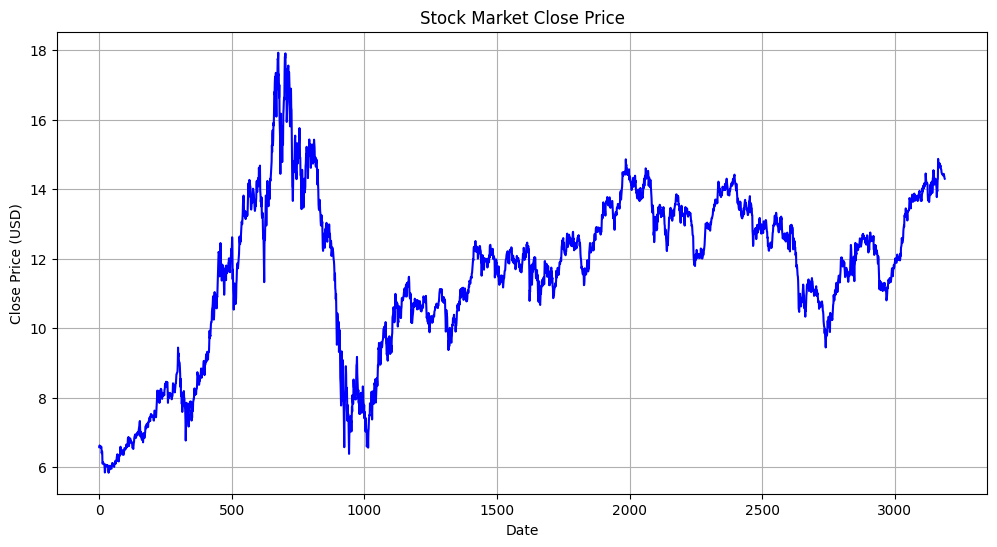

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label=['Close Price'], color = 'blue')
plt.title('Stock Market Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True)
plt.show()


In [7]:
df = df[['Close']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3190 entries, 0 to 3189
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3190 non-null   float64
dtypes: float64(1)
memory usage: 25.1 KB


In [8]:
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df)
df

,Close
0,0.060759
1,0.064979
2,0.063398
3,0.061280
4,0.062339
...,...
3185,0.711600
3186,0.708290
3187,0.706477
3188,0.701669


In [9]:
def load_data(stock, look_back):
    data_raw = stock.values # Covert into numpy array
    data = []
    
    # Create all possible sequence of length look_back
    for index in range(len(data_raw) - look_back):
        data.append(data_raw[index: index + look_back])
    data = np.array(data)
    
    test_set_size = int(np.round(0.2 * data.shape[0]))
    train_set_size = data.shape[0] - test_set_size

    x_train = data[:train_set_size, :-1, :]
    y_train = data[:train_set_size, -1, :]
    
    x_test = data[train_set_size:, :-1]
    y_test = data[train_set_size:, -1, :]

    return [x_train, y_train, x_test, y_test]

look_back = 60
x_train, y_train, x_test, y_test = load_data(df, look_back)

In [10]:
x_train.shape

(2504, 59, 1)

In [11]:
x_test.shape

(626, 59, 1)

In [12]:
y_train.shape

(2504, 1)

In [13]:
y_test.shape

(626, 1)

In [14]:
x_train = torch.from_numpy(x_train).type(torch.Tensor)
x_test = torch.from_numpy(x_test).type(torch.Tensor)
y_train = torch.from_numpy(y_train).type(torch.Tensor)
y_test = torch.from_numpy(y_test).type(torch.Tensor)

In [15]:
y_train.size(), x_train.size()

(torch.Size([2504, 1]), torch.Size([2504, 59, 1]))

In [16]:
class LSTM(nn.Module):
    def __init__(self, input_dim ,  hidden_dim, num_layers, output_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first = True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        out, _= self.lstm(x)
        return self.fc(out[:, -1, :])


In [17]:
model = LSTM(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1)

In [18]:
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [19]:
num_epochs = 100
hist = np.zeros(num_epochs)
seq_dim = look_back - 1



In [21]:
for t in range(num_epochs):
    optimizer.zero_grad()
    y_train_pred = model(x_train)
    loss = loss_fn(y_train_pred, y_train)
    if (1+ t) % 10 == 0:
        print(f'Epoch {1 + t}, MSE: {loss.item()}')
    hist[t] = loss.item()
    loss.backward()
    optimizer.step()

Epoch 10, MSE: 0.0024197895545512438
Epoch 20, MSE: 0.0019378835568204522
Epoch 30, MSE: 0.0017737426096573472
Epoch 40, MSE: 0.0016642730915918946
Epoch 50, MSE: 0.0015777713852003217
Epoch 60, MSE: 0.0015118748415261507
Epoch 70, MSE: 0.0014531505294144154
Epoch 80, MSE: 0.0014012929750606418
Epoch 90, MSE: 0.0013554039178416133
Epoch 100, MSE: 0.0013141626259312034


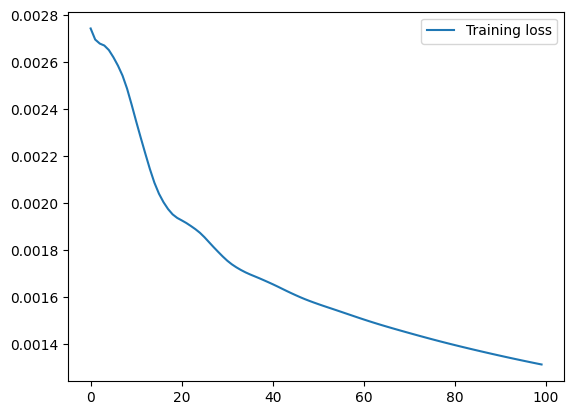

In [22]:
plt.plot(hist, label='Training loss')
plt.legend()
plt.show()

In [23]:
y_test_pred = model(x_test)


In [24]:
y_train_pred = y_train_pred.detach().numpy()
y_test_pred = y_test_pred.detach().numpy()

In [25]:
y_test_pred[:5]

array([[0.6032931 ],
       [0.6014269 ],
       [0.60050446],
       [0.5996067 ],
       [0.5984755 ]], dtype=float32)